## Load data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

df = pd.read_csv('outputs/cleaned_tickets.csv')
cat_results = pd.read_csv('outputs/category_predictions.csv')
pri_results = pd.read_csv('outputs/priority_predictions.csv')
df.shape

(8469, 4)

## Category distribution

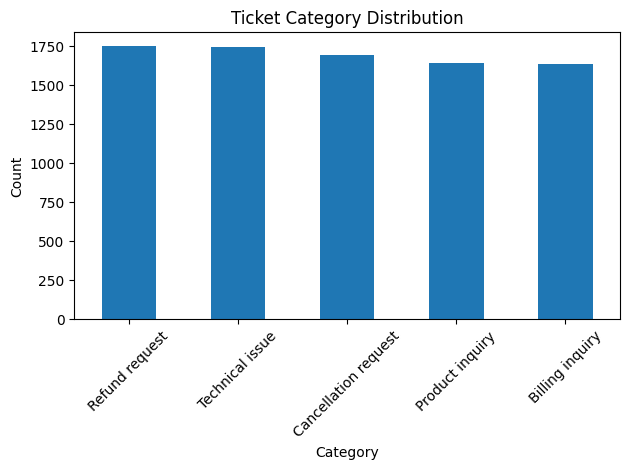

In [2]:
df['category'].value_counts().plot(kind='bar')
plt.title('Ticket Category Distribution')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Priority distribution

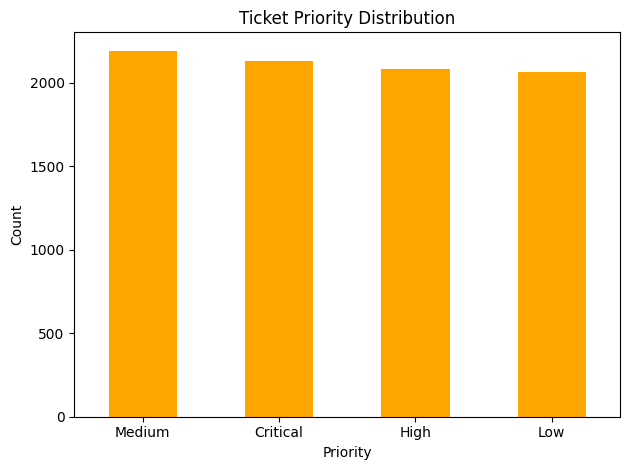

In [3]:
df['priority'].value_counts().plot(kind='bar', color='orange')
plt.title('Ticket Priority Distribution')
plt.xlabel('Priority')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Category model confusion matrix

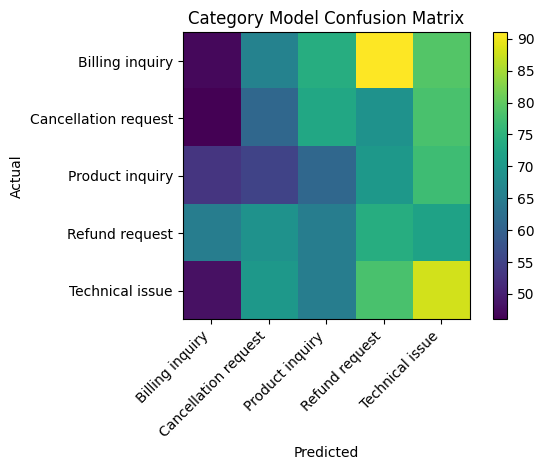

In [4]:
labels = sorted(cat_results['actual_category'].unique())
cm = confusion_matrix(cat_results['actual_category'], cat_results['predicted_category'], labels=labels)

plt.imshow(cm)
plt.title('Category Model Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(range(len(labels)), labels, rotation=45, ha='right')
plt.yticks(range(len(labels)), labels)
plt.colorbar()
plt.tight_layout()
plt.show()

## Priority model confusion matrix

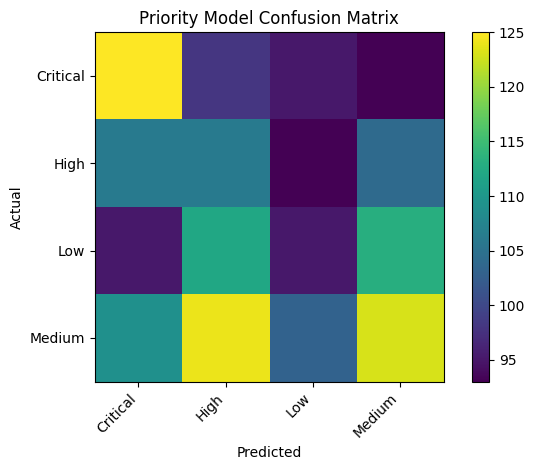

In [5]:
pri_labels = sorted(pri_results['actual_priority'].unique())
cm_pri = confusion_matrix(pri_results['actual_priority'], pri_results['predicted_priority'], labels=pri_labels)

plt.imshow(cm_pri)
plt.title('Priority Model Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(range(len(pri_labels)), pri_labels, rotation=45, ha='right')
plt.yticks(range(len(pri_labels)), pri_labels)
plt.colorbar()
plt.tight_layout()
plt.show()

## Class wise accuracy check

In [6]:
cat_results['correct'] = cat_results['actual_category'] == cat_results['predicted_category']
cat_results.groupby('actual_category')['correct'].mean()

actual_category
Billing inquiry         0.131653
Cancellation request    0.186544
Product inquiry         0.193038
Refund request          0.214493
Technical issue         0.252149
Name: correct, dtype: float64

In [7]:
pri_results['correct'] = pri_results['actual_priority'] == pri_results['predicted_priority']
pri_results.groupby('actual_priority')['correct'].mean()

actual_priority
Critical    0.304136
High        0.259169
Low         0.228916
Medium      0.267974
Name: correct, dtype: float64

## What this means for the business

The category model and the priority model both perform close to random guessing (around 20 percent for category with 5 classes, and around 27 percent for priority with 4 classes). The confusion matrices confirm this, predictions are spread fairly evenly across all classes instead of clustering along the diagonal.

The reason comes down to the dataset itself. The ticket text in this dataset is generated from repeated templates like "I'm having an issue with the {product_purchased}. Please assist." and the category and priority labels do not actually line up with what the ticket text says. So the model has no real signal to learn from, no matter how it is tuned.

In a real support operations setting this pipeline (text cleaning, TF-IDF, classification, evaluation) is exactly what would be used, but it needs a dataset where ticket text and labels are genuinely connected, for example labels assigned by actual support agents based on ticket content. With that kind of data, this same code would be expected to perform well above random guessing and could realistically be used to auto route tickets to the right team and flag high priority ones faster.